In [1]:
import math
import os
import sys
import time

# nanoVLM Imports
sys.path.append("..") 
from data.collators import VQACollator, MMStarCollator
from data.datasets import MMStarDataset, VQADataset
from data.processors import get_image_processor, get_tokenizer
from models.vision_language_model import VisionLanguageModel
import models.utils as utils
from models.config import TrainConfig, VLMConfig

# Libraries
from dataclasses import dataclass, field
from datasets import load_dataset, concatenate_datasets
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# Otherwise, the tokenizer will through a warning
os.environ["TOKENIZERS_PARALLELISM"] = "false"

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

Using device: mps


In [2]:
# Vision Transformer (ViT) config
vit_img_size = 224
vit_model_type = 'google/siglip-base-patch16-224'

# Language Model config
lm_max_length = 128
lm_model_type = 'HuggingFaceTB/SmolLM2-135M'
lm_tokenizer = 'HuggingFaceTB/cosmo2-tokenizer'

# Modality Projector config
mp_pixel_shuffle_factor = 2
mp_image_token_length = 49

hf_repo_name = 'nanoVLM'

vlm_cfg = VLMConfig(
    vit_img_size = vit_img_size,
    vit_model_type = vit_model_type,
    lm_max_length = lm_max_length,
    lm_model_type = lm_model_type,
    lm_tokenizer = lm_tokenizer,
    mp_pixel_shuffle_factor = mp_pixel_shuffle_factor,
    mp_image_token_length = mp_image_token_length,
    vlm_extra_tokens = {"image_token": "<|image|>"},
    vlm_load_backbone_weights = True,
    vlm_checkpoint_path = 'checkpoints',
    hf_repo_name = hf_repo_name,
)

In [3]:
# Learning rates
lr_mp = 1e-3
lr_backbones = 5e-5

# Use a small subset of the data at first, set it to None for using full set.
data_cutoff_idx = 1024
val_ratio = 0.2

batch_size = 12
gradient_accumulation_steps = 4
mmstar_batch_size = 32  # for mmstar-benchmark

max_grad_norm= 1.0
eval_in_epochs = False  # Deactivating in this notebook.
eval_interval = 250  # Evaluated on the validation and MMStar test datasets every 250 steps.
epochs = 5
resume_from_vlm_checkpoint = False  # Resume from checkpoint or train from scratch.

train_dataset_path = "HuggingFaceM4/the_cauldron"
train_dataset_name = ("tqa", "vsr")  # All options; ("ai2d", "aokvqa", "chart2text", "chartqa", "clevr", "cocoqa", "datikz", "diagram_image_to_text", "docvqa", "dvqa", "figureqa", "finqa", "geomverse", "hateful_memes", "hitab", "iam", "iconqa", "infographic_vqa", "intergps", "localized_narratives", "mapqa", "multihiertt", "ocrvqa", "plotqa", "raven", "rendered_text", "robut_sqa", "robut_wikisql", "robut_wtq", "scienceqa", "screen2words", "st_vqa", "tabmwp", "tallyqa", "tat_qa", "textcaps", "textvqa", "tqa", "vistext", "visual7w", "visualmrc", "vqarad", "vqav2", "vsr", "websight") # "clevr_math", "okvqa", "spot_the_diff", "nlvr2", "mimic_cgd",
test_dataset_path = "Lin-Chen/MMStar"

# wandb_entity: str = "HuggingFace" # Indicate the entity to log to in wandb
# log_wandb: bool = True

train_cfg = TrainConfig(
    lr_mp=lr_mp,
    lr_backbones=lr_backbones,
    data_cutoff_idx=data_cutoff_idx,
    val_ratio=val_ratio,
    batch_size=batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    mmstar_batch_size=mmstar_batch_size,
    max_grad_norm=max_grad_norm,
    eval_in_epochs=eval_in_epochs,
    eval_interval=eval_interval,
    epochs=epochs,
    resume_from_vlm_checkpoint=resume_from_vlm_checkpoint,
    train_dataset_path=train_dataset_path,
    train_dataset_name=train_dataset_name,
    test_dataset_path=test_dataset_path,
)

## Data preparation

In [4]:
# Check dataset
# Load and combine all training datasets
combined_train_data = []
for dataset_name in train_cfg.train_dataset_name:
    train_ds = load_dataset(train_cfg.train_dataset_path, dataset_name)
    combined_train_data.append(train_ds['train'])
train_ds = concatenate_datasets(combined_train_data)

Using the latest cached version of the dataset since HuggingFaceM4/the_cauldron couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'tqa' at /Users/yilin/.cache/huggingface/datasets/HuggingFaceM4___the_cauldron/tqa/0.0.0/847a98a779b1652d65111daf20c972dfcd333605 (last modified on Sun May 25 21:24:43 2025).
Using the latest cached version of the dataset since HuggingFaceM4/the_cauldron couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'vsr' at /Users/yilin/.cache/huggingface/datasets/HuggingFaceM4___the_cauldron/vsr/0.0.0/847a98a779b1652d65111daf20c972dfcd333605 (last modified on Sun May 25 21:24:33 2025).


In [5]:
train_ds[11]

{'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1500x825>],
 'texts': [{'user': 'Question: How many types of rock are in the picture?\nChoices:\nA. 5.\nB. 4.\nC. 2.\nD. 3.\nAnswer with the letter.',
   'assistant': 'Answer: C',
   'source': 'TQA'},
  {'user': 'Question: What is under hard rock?\nChoices:\nA. water.\nB. soft rock.\nC. nothing.\nD. stream.\nAnswer with the letter.',
   'assistant': 'Answer: B',
   'source': 'TQA'},
  {'user': 'Question: What is the empty space behind the falling water in this drawing?\nChoices:\nA. hard rock.\nB. undercutting.\nC. soft rock.\nD. cave.\nAnswer with the letter.',
   'assistant': 'Answer: B',
   'source': 'TQA'}]}

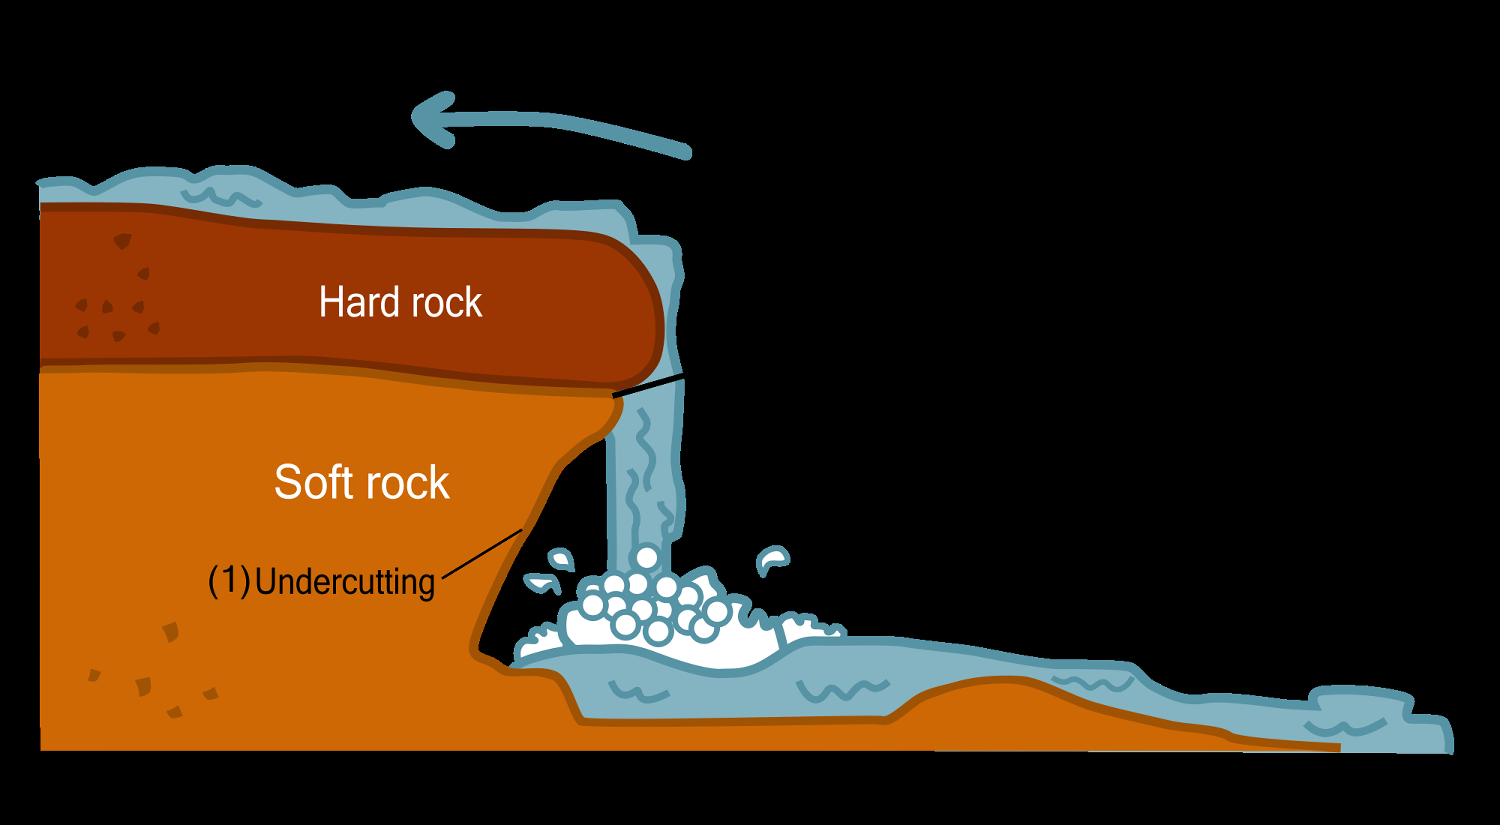

In [6]:
train_ds[11]['images'][0]

In [7]:
# Check VQADataset
train_size = 100
image_processor = get_image_processor(vlm_cfg.vit_img_size)
tokenizer = get_tokenizer(vlm_cfg.lm_tokenizer, vlm_cfg.vlm_extra_tokens)
train_dataset = VQADataset(train_ds.select(range(train_size)), tokenizer, image_processor)

In [8]:
train_dataset[11]

{'image': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 'text_data': 'Question: Question: How many types of rock are in the picture?\nChoices:\nA. 5.\nB. 4.\nC. 2.\nD. 3.\nAnswer with the letter. Answer:',
 'answer': 'Answer: C<|endofte

In [9]:
train_dataset[11]['image'].shape

torch.Size([3, 224, 224])

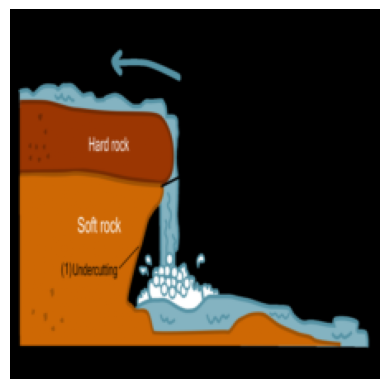

In [10]:
img = train_dataset[11]['image']
np_img = img.permute(1, 2, 0).cpu().numpy()
plt.imshow(np_img)
plt.axis('off')
plt.show()

In [11]:
vqa_collator = VQACollator(tokenizer, vlm_cfg.lm_max_length, vlm_cfg.mp_image_token_length)
train_loader = DataLoader(
    train_dataset,
    batch_size=train_cfg.batch_size,
    shuffle=False,  # Should enable shuffle in the real training process.
    collate_fn=vqa_collator,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)


In [12]:
sample = next(iter(train_loader))
print(sample.keys())
for k, v in sample.items():
    print(f"{k} shape: {v.shape}")

/Users/yilin/miniconda3/envs/vlm_study/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


dict_keys(['image', 'input_ids', 'attention_mask', 'labels'])
image shape: torch.Size([12, 3, 224, 224])
input_ids shape: torch.Size([12, 128])
attention_mask shape: torch.Size([12, 128])
labels shape: torch.Size([12, 128])


In [13]:
sample['input_ids'][0]

tensor([    0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0, 49152, 49152, 49152, 49152,
        49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152,
        49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152,
        49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152,
        49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152, 49152,
        49152, 49152, 49152, 49152, 49152, 17872,    42, 15232,    42,  1073,
          800,  3643,   359, 13178,   281,   260, 11262,    47,   198, 29943,
          943,    42,   198,    49,    30,   216,    38,    30,   198,    50,
           30,   216,    36,    30,   198,    51,    30,   216,    40,    30,
          198,    52,    30,   216,    39,    30,   198, 21350,   351,   260,
         4386,    30, 19842,    42, 21350,    42,   422,     0])

In [14]:
sample['labels'][0]

tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100, 21350,    42,   422,     0,  -100])

In [15]:
sample['attention_mask'][0]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])

In [16]:
tokenizer.batch_decode(sample['input_ids'][0])

['<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',
 '<|image|>',


In [17]:
label = torch.where(sample['labels'][0] != -100, sample['labels'][0], tokenizer.pad_token_id)
tokenizer.batch_decode(label)

['<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoft

In [18]:
# Prepare dataloaders
def get_dataloaders(train_cfg, vlm_cfg):
    # Create datasets
    image_processor = get_image_processor(vlm_cfg.vit_img_size)
    tokenizer = get_tokenizer(vlm_cfg.lm_tokenizer, vlm_cfg.vlm_extra_tokens)

    # Load and combine all training datasets
    combined_train_data = []
    for dataset_name in train_cfg.train_dataset_name:
        train_ds = load_dataset(train_cfg.train_dataset_path, dataset_name)
        combined_train_data.append(train_ds['train'])
    train_ds = concatenate_datasets(combined_train_data)
    
    test_ds = load_dataset(train_cfg.test_dataset_path)
    train_ds = train_ds.shuffle(seed=0) # Shuffle the training dataset, so train and val get equal contributions from all concatinated datasets

    # Apply cutoff if specified
    if train_cfg.data_cutoff_idx is None:
        total_samples = len(train_ds)  # Use the entire dataset
    else:
        total_samples = min(len(train_ds), train_cfg.data_cutoff_idx)

    val_size = int(total_samples * train_cfg.val_ratio)
    train_size = total_samples - val_size

    train_dataset = VQADataset(train_ds.select(range(train_size)), tokenizer, image_processor)
    val_dataset = VQADataset(train_ds.select(range(train_size, total_samples)), tokenizer, image_processor)
    test_dataset = MMStarDataset(test_ds['val'], tokenizer, image_processor)

    # Create collators
    vqa_collator = VQACollator(tokenizer, vlm_cfg.lm_max_length, vlm_cfg.mp_image_token_length)
    mmstar_collator = MMStarCollator(tokenizer, vlm_cfg.mp_image_token_length)

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_cfg.batch_size,
        shuffle=True,
        collate_fn=vqa_collator,
        num_workers=2,
        pin_memory=True,
        drop_last=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=train_cfg.batch_size,
        shuffle=False,
        collate_fn=vqa_collator,
        num_workers=2,
        pin_memory=True,
        drop_last=True,
    )

    test_loader = DataLoader(
        test_dataset, 
        batch_size=train_cfg.mmstar_batch_size, 
        shuffle=False, 
        collate_fn=mmstar_collator,
        pin_memory=True,
        )

    return train_loader, val_loader, test_loader

## Model Architecture

In [19]:
train_loader, val_loader, test_loader = get_dataloaders(train_cfg, vlm_cfg)
tokenizer = get_tokenizer(vlm_cfg.lm_tokenizer, vlm_cfg.vlm_extra_tokens)

# Initialize model
if train_cfg.resume_from_vlm_checkpoint:
    model = VisionLanguageModel.from_pretrained(vlm_cfg.vlm_checkpoint_path)
else:
    model = VisionLanguageModel(vlm_cfg)

print(f"nanoVLM initialized with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Training summary: {len(train_loader.dataset)} samples, {len(train_loader)} batches/epoch, batch size {train_cfg.batch_size}")

# Define optimizer groups
param_groups = [{'params': model.MP.parameters(), 'lr': train_cfg.lr_mp},
                {'params': list(model.decoder.parameters()) + list(model.vision_encoder.parameters()), 'lr': train_cfg.lr_backbones}]
optimizer = optim.AdamW(param_groups)

model.to(device)

epoch_times = []
batch_losses = []
val_losses = []
val_plot_steps = []
best_accuracy = 0
global_step = 0


Using the latest cached version of the dataset since HuggingFaceM4/the_cauldron couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'tqa' at /Users/yilin/.cache/huggingface/datasets/HuggingFaceM4___the_cauldron/tqa/0.0.0/847a98a779b1652d65111daf20c972dfcd333605 (last modified on Sun May 25 21:24:43 2025).
Using the latest cached version of the dataset since HuggingFaceM4/the_cauldron couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'vsr' at /Users/yilin/.cache/huggingface/datasets/HuggingFaceM4___the_cauldron/vsr/0.0.0/847a98a779b1652d65111daf20c972dfcd333605 (last modified on Sun May 25 21:24:33 2025).
Using the latest cached version of the dataset since Lin-Chen/MMStar couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'val' at /Users/yilin/.cache/huggingface/datasets/Lin-Chen___mm_star/val/0.0.0/bc98d668301da7b14f648724866e57302778ab27 (last modified on Sun May 25 21:24:43

Loading from backbone weights
Successfully loaded google/siglip-base-patch16-224 weights from safetensors. Model has 85,797,120 parameters.
Extending token embeddings from torch.Size([49152, 576]) to torch.Size([49153, 576])
Initialized 1 new token embeddings
Successfully loaded HuggingFaceTB/SmolLM2-135M weights from safetensors. Model has 134,515,584 parameters.
nanoVLM initialized with 222,082,176 parameters
Training summary: 820 samples, 68 batches/epoch, batch size 12


In [20]:
model

VisionLanguageModel(
  (vision_encoder): ViT(
    (patch_embedding): ViTPatchEmbeddings(
      (conv): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
    )
    (dropout): Dropout(p=0.0, inplace=False)
    (blocks): ModuleList(
      (0-11): 12 x ViTBlock(
        (ln1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): ViTMultiHeadAttention(
          (qkv_proj): Linear(in_features=768, out_features=2304, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (attn_dropout): Dropout(p=0.0, inplace=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
        )
        (ln2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELU(approximate='tanh')
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
   

In [21]:
model.train()

batch = next(iter(train_loader))
images = batch['image'].to(device)
input_ids = batch['input_ids'].to(device)
labels = batch['labels'].to(device)
attention_mask = batch['attention_mask'].to(device)

optimizer.zero_grad()
with torch.autocast(device_type=device, dtype=torch.float16):  # Mixed precision training
    _, loss = model(input_ids, images, attention_mask=attention_mask, targets=labels)
# VLM - input image shape: torch.Size([12, 3, 224, 224])
# VLM - after vision_encoder, image embedding shape: torch.Size([12, 196, 768])
# ModalityProjector input shape: torch.Size([12, 196, 768])
# ModalityProjector after pixel_shuffle shape: torch.Size([12, 49, 3072])
# ModalityProjector after projection shape: torch.Size([12, 49, 576])
# VLM - after modality_projector, image embedding shape: torch.Size([12, 49, 576])
# VLM - after token_embedding, token embedding shape: torch.Size([12, 128, 576])
# VLM - after replacing image tokens, updated token embedding shape: torch.Size([12, 128, 576])
# VLM - after LLM decoder, logits shape: torch.Size([12, 128, 576])

VLM - input image shape: torch.Size([12, 3, 224, 224])
VLM - after vision_encoder, image embedding shape: torch.Size([12, 196, 768])
ModalityProjector input shape: torch.Size([12, 196, 768])
ModalityProjector after pixel_shuffle shape: torch.Size([12, 49, 3072])
ModalityProjector after projection shape: torch.Size([12, 49, 576])
VLM - after modality_projector, image embedding shape: torch.Size([12, 49, 576])
VLM - after token_embedding, token embedding shape: torch.Size([12, 128, 576])
VLM - after replacing image tokens, updated token embedding shape: torch.Size([12, 128, 576])
VLM - after LLM decoder, logits shape: torch.Size([12, 128, 576])
